In [ ]:
import pandas as pd
import requests
from io import StringIO #questo è importante per la questione del dataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler



In [22]:
#importare i dati sul territorio
comuni = pd.read_csv("Comuni - Dimensione Data Indagine 31-12-2020 Stampa 19062026105027.csv", sep = ";")

In [23]:
comuni.shape

(7903, 17)

In [24]:
comuni.columns

Index(['Codice Ripartizione geografica', 'Codice Regione',
       'Codice Provincia (Storico)', 'Codice Provincia/Uts',
       'Codice Comune (alfanumerico)', 'Codice Comune (numerico)', 'Comune',
       'Comune (dizione straniera)', 'Sigla automobilistica',
       'Capoluogo di Provincia/Uts', 'Capoluogo di Regione',
       'Popolazione legale', 'Anno Censimento', 'Superficie (Kmq)',
       'Anno (Superficie)', 'Popolazione residente',
       'Anno (Popolazione residente)'],
      dtype='str')

In [25]:
#importare i dati sugli incidenti (URL API)
url = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"
#bisogna scaricare i dati come CSV quindi:
dati_incidenti=requests.get(url, headers={"Accept": "application/vnd.sdmx.data+csv;version=1.0.0"})
# usando StringIO evitiamo di salvare il CSV sul disco e permettiamo a pandas di leggerlo 
incidenti = pd.read_csv(StringIO(dati_incidenti.text))



In [26]:
#esploro i dati
print(incidenti.columns.tolist())
print(incidenti.head())
print(incidenti.shape)

['DATAFLOW', 'FREQ', 'REF_AREA', 'DATA_TYPE', 'RESULT', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_STATUS', 'NOTE_DS', 'NOTE_REF_AREA', 'NOTE_DATA_TYPE', 'NOTE_RESULT', 'NOTE_TIME_PERIOD', 'BASE_PER', 'UNIT_MEAS', 'UNIT_MULT']
          DATAFLOW FREQ  REF_AREA DATA_TYPE RESULT  TIME_PERIOD  OBS_VALUE  \
0  IT1:41_983(1.0)    A      1001   KILLINJ      F         2001         10   
1  IT1:41_983(1.0)    A      1001   KILLINJ      F         2002         10   
2  IT1:41_983(1.0)    A      1001   KILLINJ      F         2003          7   
3  IT1:41_983(1.0)    A      1001   KILLINJ      F         2004         13   
4  IT1:41_983(1.0)    A      1001   KILLINJ      F         2005          2   

   OBS_STATUS  NOTE_DS  NOTE_REF_AREA  NOTE_DATA_TYPE  NOTE_RESULT  \
0         NaN      NaN            NaN             NaN          NaN   
1         NaN      NaN            NaN             NaN          NaN   
2         NaN      NaN            NaN             NaN          NaN   
3         NaN      NaN            

In [27]:
#visto che ci sono diversi NaN eliminiamoli e verifichiamo che siano stati effettivamente eliminati facendo ancora totlist
incidenti = incidenti.dropna(axis=1, how="all")
print(incidenti.columns.tolist())

['DATAFLOW', 'FREQ', 'REF_AREA', 'DATA_TYPE', 'RESULT', 'TIME_PERIOD', 'OBS_VALUE']


In [28]:
print(incidenti["REF_AREA"].unique()[:50])
print(incidenti["REF_AREA"].dtype)

[1001 1002 1003 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013 1014
 1015 1016 1017 1018 1019 1020 1021 1022 1023 1024 1025 1026 1027 1028
 1029 1030 1031 1032 1033 1034 1035 1036 1037 1038 1039 1040 1041 1042
 1043 1044 1045 1046 1047 1048 1049 1050]
int64


In [29]:
print(incidenti["REF_AREA"].nunique())

8578


In [30]:
print(comuni.columns.tolist())
print(comuni.head())
#ora so che i codici del dataset precedente corrispondono ai comuni quindi so dove joinare

['Codice Ripartizione geografica', 'Codice Regione', 'Codice Provincia (Storico)', 'Codice Provincia/Uts', 'Codice Comune (alfanumerico)', 'Codice Comune (numerico)', 'Comune', 'Comune (dizione straniera)', 'Sigla automobilistica', 'Capoluogo di Provincia/Uts', 'Capoluogo di Regione', 'Popolazione legale', 'Anno Censimento', 'Superficie (Kmq)', 'Anno (Superficie)', 'Popolazione residente', 'Anno (Popolazione residente)']
   Codice Ripartizione geografica  Codice Regione  Codice Provincia (Storico)  \
0                               1               1                           1   
1                               1               1                           1   
2                               1               1                           1   
3                               1               1                           1   
4                               1               1                           1   

   Codice Provincia/Uts  Codice Comune (alfanumerico)  \
0                   201        

In [31]:
#facciamo la join
df = incidenti.merge(comuni,
left_on="REF_AREA",
right_on="Codice Comune (numerico)",
how="left")
#verifichiamo che funziona
print(df[["REF_AREA", "Comune"]].head())

   REF_AREA Comune
0      1001  Agliè
1      1001  Agliè
2      1001  Agliè
3      1001  Agliè
4      1001  Agliè


In [32]:
#ora faccio un df con solo gli incidenti stradali, killinj sta per morti e feriti ma ddobbiamo concentrarci sugli INCIDENTI
incidenti_stradali = df[df["DATA_TYPE"] == "ROADACC"]

In [33]:
#vediamo quanti incidenti per mille abitanti ci sono facendo una divisione tra gli incidenti (obs value) e la popolazione
incidenti_stradali["incidenti_per_mille_abitanti"] = (
incidenti_stradali["OBS_VALUE"] /
incidenti_stradali["Popolazione residente"] * 1000)
#ho moltiplicato per mille per renerlo più intuitivo altrimenti non si avrebbe avuto la percezione effettiva del numero degli incidenti

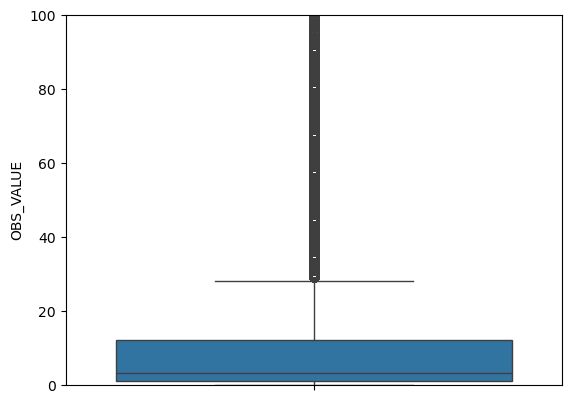

In [34]:
#vediamo se ci sono outliers con un grafico mettendo limite 100
sns.boxplot(y=incidenti_stradali["OBS_VALUE"])
plt.ylim(0, 100)
plt.show()
#già si capisce che ci sono molti ouliers probabilmente perchè in città piu grandi ci sono piu incidenti, dobbiamo tenerli in considerazione 
#perchè non è un errore ma sono dati reali

In [35]:
#vediamo quali comuni hanno piu incidenti (gruppando comuni) e ordiniamo per valori decrescenti
top10 = incidenti_stradali.groupby("Comune")["OBS_VALUE"].sum()
top10 = top10.sort_values(ascending=False)
print(top10.head(10))
#come ci si poteva aspettare le città più popolose presentano più incidenti

Comune
Roma       390605
Milano     272545
Genova     102694
Torino      87227
Firenze     74537
Napoli      60731
Palermo     54030
Bologna     53858
Bari        44172
Verona      36503
Name: OBS_VALUE, dtype: int64


In [36]:
#preparo i dati per la regressione
dati_regressione = incidenti_stradali.dropna(subset=["Popolazione residente", "OBS_VALUE"])#togliamo eventuali NaN
X = dati_regressione[["Popolazione residente"]]
y = dati_regressione["OBS_VALUE"]

In [37]:
#faccio il modello
modello = LinearRegression()
modello.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
#calcoliamo R^2
r2 = modello.score(X, y)
print("R²:", r2)
#86%! si vede che il numero della popolazione spiega il numero di incidenti

R²: 0.8685689443588089


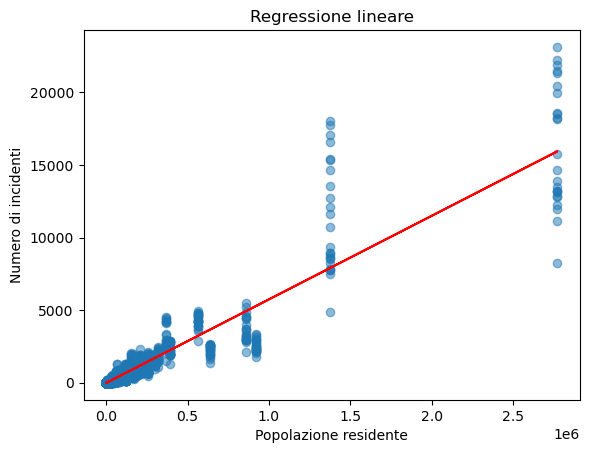

In [39]:
#ora facciamo il grafico
plt.scatter(dati_regressione["Popolazione residente"],
dati_regressione["OBS_VALUE"],alpha=0.5)
y_pred = modello.predict(X)#predict degli incidenti in base alla popolazione
plt.plot(dati_regressione["Popolazione residente"],y_pred,color="red")
plt.xlabel("Popolazione residente")
plt.ylabel("Numero di incidenti")
plt.title("Regressione lineare")
plt.show()

In [40]:
#p value ecc.
X_stats = sm.add_constant(X)
modello_stats = sm.OLS(y, X_stats)
risultati = modello_stats.fit()
print(risultati.summary())

                            OLS Regression Results                            
Dep. Variable:              OBS_VALUE   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                 1.209e+06
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        14:13:56   Log-Likelihood:            -1.0931e+06
No. Observations:              182895   AIC:                         2.186e+06
Df Residuals:                  182893   BIC:                         2.186e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   -18.07

In [41]:
#nella cella sotto stavo creando una nuova variabile ma un valore non tornava quindi converto a float
#bisogna convertire in float perchè c'era un numero anomalo
#convertiamo la colonna in stringa
incidenti_stradali["Superficie (Kmq)"] = incidenti_stradali["Superficie (Kmq)"].astype(str)
#eliminiamo il punto usato come separatore delle migliaia
incidenti_stradali["Superficie (Kmq)"] = incidenti_stradali["Superficie (Kmq)"].str.replace(".", "", regex=False)
#sostituiamo la virgola con il punto decimale
incidenti_stradali["Superficie (Kmq)"] = incidenti_stradali["Superficie (Kmq)"].str.replace(",", ".", regex=False)
#convertiamo la colonna in float
incidenti_stradali["Superficie (Kmq)"] = incidenti_stradali["Superficie (Kmq)"].astype(float)

In [42]:
#crao la variabile incidendi per kmq
incidenti_stradali["incidenti_per_kmq"] = (
incidenti_stradali["OBS_VALUE"] /
incidenti_stradali["Superficie (Kmq)"])

In [43]:
print(incidenti_stradali["Superficie (Kmq)"].dtype)

float64


In [ ]:
# Eliminiamo le righe che non hanno valori validi
# per poter fare il clustering
incidenti_stradali = incidenti_stradali.dropna(subset=["incidenti_per_mille_abitanti", "incidenti_per_kmq"])

In [60]:
#seleziono le variabili
X = incidenti_stradali[["incidenti_per_mille_abitanti","incidenti_per_kmq"]]

In [61]:
#normalizzo i dati
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

In [ ]:
#k means
kmeans = KMeans(n_clusters=3, random_state=42)
cluster = kmeans.fit_predict(X_norm)

In [64]:
#aggiungiamo il cluster al df
incidenti_stradali["cluster"] = cluster

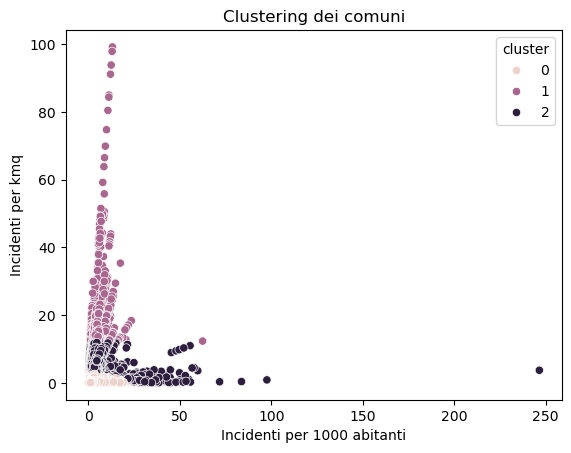

In [66]:
sns.scatterplot(data=incidenti_stradali,
x="incidenti_per_mille_abitanti",
y="incidenti_per_kmq",
hue="cluster")

plt.xlabel("Incidenti per 1000 abitanti")
plt.ylabel("Incidenti per kmq")
plt.title("Clustering dei comuni")
plt.show()

In [69]:
#devo usare la virgola come separatore decimale altrimenti power bi non lo legge bene e restituisce numeri assurdi
incidenti_stradali.to_csv("incidenti_stradali_finale.csv",sep=";",decimal=",",index=False)